# Phase 1 — SimCLR Baseline Training

Self-supervised contrastive pre-training on CIFAR-10 with a modified ResNet-18,
followed by linear probing.

**Pipeline**
1. SimCLR SSL for `epochs` epochs (200 for full run)
2. kNN monitor every 5 epochs
3. Linear probe (100 epochs, fixed protocol)

Shared components live in `utils.py`.


In [1]:
# --- Cell 1: Imports & Config ---
import json, time, os, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    CIFAR10_MEAN, CIFAR10_STD,
    get_device, get_cifar_resnet18, SimCLRModel,
    nt_xent_loss, SimCLRPairDataset,
    get_simclr_transform, get_eval_transform,
    knn_monitor,
)

# Toggle: set False for the full 200-epoch run.
SMOKE_TEST = False

cfg = dict(
    batch_size   = 256,
    epochs       = 3 if SMOKE_TEST else 200,
    lr           = 3e-4,
    weight_decay = 1e-6,
    temperature  = 0.5,
    projector_dim= 128,
    hidden_dim   = 512,
    knn_k        = 20,
    knn_interval = 1 if SMOKE_TEST else 5,
    seed         = 42,
    num_workers  = 0,  # Windows + DirectML + exec-based cell runner: 0 is the reliable choice
    data_root    = './data',
    ckpt_path    = 'models/simclr_baseline.pth' if not SMOKE_TEST else 'models/simclr_smoke.pth',
    log_path     = 'results/simclr_baseline_log.json' if not SMOKE_TEST else 'results/simclr_smoke_log.json',
    probe_path   = 'results/simclr_baseline_linear_probe.json' if not SMOKE_TEST else 'results/simclr_smoke_linear_probe.json',
    fig_path     = 'figures/simclr_baseline_curves.png' if not SMOKE_TEST else 'figures/simclr_smoke_curves.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])

device = get_device()
print('Device:', device)
print('Config:', cfg)


Device: privateuseone:0
Config: {'batch_size': 256, 'epochs': 200, 'lr': 0.0003, 'weight_decay': 1e-06, 'temperature': 0.5, 'projector_dim': 128, 'hidden_dim': 512, 'knn_k': 20, 'knn_interval': 5, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'ckpt_path': 'models/simclr_baseline.pth', 'log_path': 'results/simclr_baseline_log.json', 'probe_path': 'results/simclr_baseline_linear_probe.json', 'fig_path': 'figures/simclr_baseline_curves.png'}


In [2]:
# --- Cell 2: Data Loading ---
# Base datasets WITHOUT a transform (PIL images) — SimCLRPairDataset applies transform twice.
train_base = CIFAR10(cfg['data_root'], train=True,  download=True, transform=None)
test_base  = CIFAR10(cfg['data_root'], train=False, download=True, transform=None)

ssl_train_ds = SimCLRPairDataset(train_base, get_simclr_transform(32))

# For kNN monitor + linear probe we need raw (image, label) with eval transform.
eval_transform = get_eval_transform(32)
train_eval_ds = CIFAR10(cfg['data_root'], train=True,  download=False, transform=eval_transform)
test_eval_ds  = CIFAR10(cfg['data_root'], train=False, download=False, transform=eval_transform)

ssl_loader = DataLoader(
    ssl_train_ds, batch_size=cfg['batch_size'], shuffle=True,
    num_workers=cfg['num_workers'], pin_memory=False, drop_last=True, persistent_workers=cfg['num_workers']>0,
)
memory_loader = DataLoader(
    train_eval_ds, batch_size=512, shuffle=False,
    num_workers=cfg['num_workers'], pin_memory=False, persistent_workers=cfg['num_workers']>0,
)
test_loader = DataLoader(
    test_eval_ds, batch_size=512, shuffle=False,
    num_workers=cfg['num_workers'], pin_memory=False, persistent_workers=cfg['num_workers']>0,
)

print(f'ssl_train={len(ssl_train_ds)} | test={len(test_eval_ds)}')
v1, v2, y = ssl_train_ds[0]
print(f'pair shapes: {tuple(v1.shape)}, {tuple(v2.shape)} | label={y}')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
ssl_train=50000 | test=10000
pair shapes: (3, 32, 32), (3, 32, 32) | label=6


In [3]:
# --- Cell 3: Model ---
model = SimCLRModel(hidden_dim=cfg['hidden_dim'], proj_dim=cfg['projector_dim']).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'SimCLR model — total params: {n_params/1e6:.2f}M')


SimCLR model — total params: 11.50M


In [4]:
# --- Cell 4: Loss & forward-pass sanity ---
model.train()
v1, v2, _ = next(iter(ssl_loader))
v1, v2 = v1.to(device), v2.to(device)
_, z1 = model(v1); _, z2 = model(v2)
z = torch.cat([z1, z2], dim=0)
loss = nt_xent_loss(z, cfg['temperature'])
print(f'initial batch loss ~= {loss.item():.4f}  (upper bound ~= log(2N-1) = {math.log(2*v1.size(0)-1):.3f})')


initial batch loss ~= 6.1982  (upper bound ~= log(2N-1) = 6.236)


In [5]:
# --- Cell 5: kNN monitor sanity (random init) ---
acc = knn_monitor(model.backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
print(f'kNN acc @ random init: {acc*100:.2f}%  (random guess = 10%)')


kNN acc @ random init: 38.65%  (random guess = 10%)


In [6]:
# --- Cell 6: Training Loop ---
optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

log = {'epoch': [], 'loss': [], 'knn_epoch': [], 'knn_acc': [], 'epoch_sec': []}
os.makedirs('models', exist_ok=True); os.makedirs('results', exist_ok=True)

start_epoch = 1
# --- Resume logic ---
# Set FORCE_RESTART = True to discard any existing checkpoint and train from scratch.
FORCE_RESTART = False
if (not FORCE_RESTART) and os.path.exists(cfg['ckpt_path']):
    ckpt = torch.load(cfg['ckpt_path'], map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state']); model.to(device)
    if 'optimizer_state' in ckpt: optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'log' in ckpt: log = ckpt['log']
    start_epoch = ckpt.get('epoch', 0) + 1
    print(f"RESUMING from {cfg['ckpt_path']} at epoch {start_epoch} (done {ckpt.get('epoch', 0)}/{cfg['epochs']}).", flush=True)
else:
    print(f"Starting fresh. Checkpoint saved every epoch to {cfg['ckpt_path']}.", flush=True)

for epoch in range(start_epoch, cfg['epochs']+1):
    model.train()
    t0 = time.time()
    loss_sum, n_batches = 0.0, 0
    pbar = tqdm(ssl_loader, desc=f'Epoch {epoch}/{cfg["epochs"]}', leave=False)
    for v1, v2, _ in pbar:
        v1 = v1.to(device, non_blocking=False)
        v2 = v2.to(device, non_blocking=False)
        _, z1 = model(v1)
        _, z2 = model(v2)
        z = torch.cat([z1, z2], dim=0)
        loss = nt_xent_loss(z, cfg['temperature'])
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        # Avoid .item() per step (slow on DirectML); accumulate on GPU then sync at epoch end.
        loss_sum += float(loss.detach().cpu())
        n_batches += 1
    epoch_loss = loss_sum / max(1, n_batches)
    dt = time.time() - t0
    log['epoch'].append(epoch); log['loss'].append(epoch_loss); log['epoch_sec'].append(dt)
    msg = f'[epoch {epoch:3d}/{cfg["epochs"]}] loss={epoch_loss:.4f}  time={dt:.1f}s'

    if epoch % cfg['knn_interval'] == 0 or epoch == cfg['epochs']:
        acc = knn_monitor(model.backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
        log['knn_epoch'].append(epoch); log['knn_acc'].append(acc)
        msg += f'  | kNN={acc*100:.2f}%'
    print(msg, flush=True)

    # Atomic checkpoint every epoch (write .tmp then rename — crash-safe).
    tmp_path = cfg['ckpt_path'] + '.tmp'
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'log': log,
        'config': cfg,
    }, tmp_path)
    os.replace(tmp_path, cfg['ckpt_path'])
    with open(cfg['log_path'], 'w') as f: json.dump(log, f, indent=2)

print('Training complete. Final kNN:', log['knn_acc'][-1] if log['knn_acc'] else 'n/a')
print('Checkpoint:', cfg['ckpt_path'])


RESUMING from models/simclr_baseline.pth at epoch 195 (done 194/200).


Epoch 195/200:   0%|          | 0/195 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


[epoch 195/200] loss=4.4876  time=104.6s  | kNN=84.74%


Epoch 196/200:   0%|          | 0/195 [00:00<?, ?it/s]

...

[epoch 198/200] loss=4.4845  time=103.4s


Epoch 199/200:   0%|          | 0/195 [00:00<?, ?it/s]

[epoch 199/200] loss=4.5053  time=104.7s


Epoch 200/200:   0%|          | 0/195 [00:00<?, ?it/s]

[epoch 200/200] loss=4.5004  time=105.4s  | kNN=84.54%
Training complete. Final kNN: 0.8454
Checkpoint: models/simclr_baseline.pth


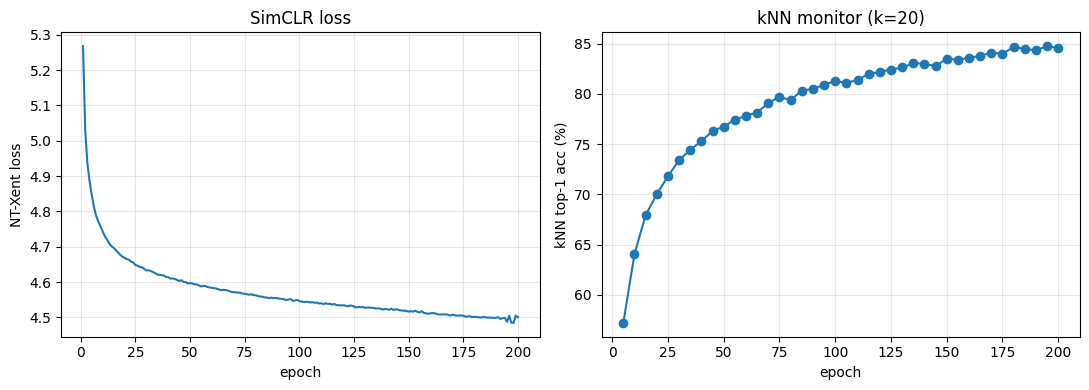

Saved figures/simclr_baseline_curves.png


In [7]:
# --- Cell 7: Learning-curve plots ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log['epoch'], log['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('NT-Xent loss'); axes[0].set_title('SimCLR loss')
axes[0].grid(alpha=0.3)

axes[1].plot(log['knn_epoch'], [a*100 for a in log['knn_acc']], marker='o')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('kNN top-1 acc (%)')
axes[1].set_title(f'kNN monitor (k={cfg["knn_k"]})')
axes[1].grid(alpha=0.3)
fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig(cfg['fig_path'], dpi=150)
plt.show()
print('Saved', cfg['fig_path'])


In [8]:
# --- Cell 8: Linear Probing ---
# Load the saved backbone weights and train a linear head with the FIXED protocol.
ckpt = torch.load(cfg['ckpt_path'], map_location='cpu', weights_only=False)
probe_backbone = get_cifar_resnet18().to(device)
# Filter backbone-only params from the SimCLR state_dict
bb_state = {k[len('backbone.'):]: v for k, v in ckpt['model_state'].items() if k.startswith('backbone.')}
missing, unexpected = probe_backbone.load_state_dict(bb_state, strict=False)
print('loaded backbone  | missing:', len(missing), '| unexpected:', len(unexpected))
for p in probe_backbone.parameters(): p.requires_grad = False
probe_backbone.eval()

classifier = nn.Linear(512, 10).to(device)
opt_probe  = torch.optim.Adam(classifier.parameters(), lr=1e-3, weight_decay=1e-6)

probe_train_loader = DataLoader(
    train_eval_ds, batch_size=cfg['batch_size'], shuffle=True,
    num_workers=cfg['num_workers'], pin_memory=False, persistent_workers=cfg['num_workers']>0,
)

probe_epochs = 20 if SMOKE_TEST else 100
probe_log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}

@torch.no_grad()
def _eval_probe(loader):
    classifier.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        h = probe_backbone(x)
        pred = classifier(h).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return correct/total

for ep in range(1, probe_epochs+1):
    classifier.train()
    loss_sum = corr = tot = 0
    for x, y in probe_train_loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad(): h = probe_backbone(x)
        logits = classifier(h)
        loss = F.cross_entropy(logits, y)
        opt_probe.zero_grad(set_to_none=True); loss.backward(); opt_probe.step()
        loss_sum += float(loss.detach().cpu()) * y.size(0)
        corr += (logits.argmax(1) == y).sum().item(); tot += y.size(0)
    train_loss = loss_sum/tot; train_acc = corr/tot
    test_acc = _eval_probe(test_loader)
    probe_log['epoch'].append(ep)
    probe_log['train_loss'].append(train_loss)
    probe_log['train_acc'].append(train_acc)
    probe_log['test_acc'].append(test_acc)
    if ep == 1 or ep % 5 == 0 or ep == probe_epochs:
        print(f'probe epoch {ep:3d}/{probe_epochs} | loss={train_loss:.4f} train={train_acc*100:.2f}% test={test_acc*100:.2f}%', flush=True)

final = {'final_test_acc': probe_log['test_acc'][-1], 'best_test_acc': max(probe_log['test_acc']), 'curve': probe_log, 'smoke_test': SMOKE_TEST}
with open(cfg['probe_path'], 'w') as f: json.dump(final, f, indent=2)
print(f"\nLinear probe — final test acc = {final['final_test_acc']*100:.2f}%  (best {final['best_test_acc']*100:.2f}%)")
print('Saved', cfg['probe_path'])


loaded backbone  | missing: 0 | unexpected: 0
probe epoch   1/100 | loss=0.6408 train=80.89% test=84.00%
probe epoch   5/100 | loss=0.3843 train=86.50% test=85.36%
probe epoch  10/100 | loss=0.3611 train=87.29% test=85.70%
probe epoch  15/100 | loss=0.3484 train=87.59% test=86.21%
probe epoch  20/100 | loss=0.3392 train=87.90% test=86.16%
probe epoch  25/100 | loss=0.3326 train=88.19% test=86.45%
probe epoch  30/100 | loss=0.3281 train=88.34% test=86.62%
probe epoch  35/100 | loss=0.3237 train=88.45% test=86.57%
probe epoch  40/100 | loss=0.3204 train=88.59% test=86.33%
probe epoch  45/100 | loss=0.3168 train=88.61% test=86.10%
probe epoch  50/100 | loss=0.3147 train=88.72% test=86.42%
probe epoch  55/100 | loss=0.3128 train=88.76% test=86.56%
probe epoch  60/100 | loss=0.3104 train=88.90% test=86.58%
probe epoch  65/100 | loss=0.3089 train=88.99% test=86.42%
probe epoch  70/100 | loss=0.3077 train=89.01% test=86.52%
probe epoch  75/100 | loss=0.3048 train=89.13% test=86.59%
probe epoc